# Predictive Modeling Using Machine Learning

## 1. Project Introduction

### Project Overview
This project aims to introduce the fundamental concepts and practical application of machine learning for predictive modeling. We will follow a standard data science workflow, from data loading and preprocessing to model building, evaluation, and deployment, providing a hands-on experience in solving a real-world problem using machine learning techniques.

### Objective
The primary objective is to build a robust machine learning model that can accurately predict outcomes based on a given dataset. This involves understanding the data, preparing it for modeling, training various algorithms, and evaluating their performance to select the best fit.

### Expected Outcome
By the end of this project, you will have a well-documented and executable Google Colab notebook showcasing a complete machine learning pipeline. This notebook will serve as a foundational portfolio piece, demonstrating your understanding of machine learning principles and practical implementation skills.

### Workflow
Our workflow will cover the following key stages:
1.  **Project Introduction**: Defining the project scope, objectives, and workflow.
2.  **Import Libraries**: Loading essential Python libraries for data manipulation, analysis, and modeling.
3.  **Load Dataset**: Importing the dataset and performing initial data inspection.
4.  **Data Preprocessing**: Cleaning and preparing the data for machine learning algorithms.
5.  **Exploratory Data Analysis (EDA)**: Visualizing data to uncover patterns, insights, and relationships.
6.  **Feature Selection**: Identifying relevant input features and the target variable.
7.  **Split the Dataset**: Dividing the data into training and testing sets.
8.  **Build Machine Learning Models**: Training various predictive models.
9.  **Model Evaluation**: Assessing model performance using appropriate metrics.
10. **Compare Models**: Analyzing the strengths and weaknesses of different models.
11. **Feature Importance**: Understanding which features contribute most to predictions.
12. **Make Predictions**: Using the best model to make predictions on new data.
13. **Conclusion**: Summarizing findings and suggesting future improvements.
14. **Save Model**: Persisting the trained model for future use.
15. **Export Files**: Saving predictions and the trained model.

## 2. Import Libraries

In this section, we will import all the necessary Python libraries that will be used throughout our machine learning project. Each library serves a specific purpose in our data science workflow.

In [1]:
# Core Libraries for Data Manipulation and Numerical Operations
import pandas as pd  # Used for data manipulation and analysis, especially with DataFrames.
import numpy as np   # Used for numerical operations, especially with arrays and mathematical functions.

# Libraries for Data Visualization
import matplotlib.pyplot as plt # Core library for creating static, interactive, and animated visualizations.
import seaborn as sns           # Built on Matplotlib, provides a high-level interface for drawing attractive statistical graphics.

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split # Utility for splitting datasets into training and testing sets.
from sklearn.preprocessing import LabelEncoder, StandardScaler # Tools for data transformation (e.g., encoding categorical data, scaling numerical features).
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report # Metrics for evaluating classification models.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Metrics for evaluating regression models.

# Machine Learning Models
from sklearn.linear_model import LinearRegression, LogisticRegression # Linear models for regression and classification.
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor # Tree-based models for classification and regression.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # Ensemble models for classification and regression.

# Library for saving and loading models
import joblib

# Configure plot styles for better aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Dataset

In this crucial step, we will load our dataset into the Colab environment. For this project, we'll assume the dataset is in CSV format. Google Colab provides a straightforward way to upload files directly from your local machine or mount Google Drive.

### How to Upload a CSV File:

1.  **Option 1 (Temporary Upload)**: Click on the 'Files' icon on the left sidebar (folder icon). Then click on the 'Upload to session storage' icon (page with an arrow pointing up). Select your `dataset.csv` file.
2.  **Option 2 (Google Drive - Recommended for Persistence)**:
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    # Then, you can access your file like: '/content/drive/My Drive/path/to/your/dataset.csv'
    ```

For this notebook, we will proceed assuming the CSV file named `dataset.csv` has been uploaded to the session storage or its path is correctly specified.

<p style='background-color:#fff7e6;color:#e67e22;padding:10px;border-radius:5px;'><b>Note:</b> For demonstration purposes and to ensure the notebook runs smoothly, I'm temporarily using a sample dataset from Colab's environment (`/content/sample_data/california_housing_train.csv`). You can replace `dataset_path` in the next cell with the path to your actual dataset once it's uploaded or mounted from Google Drive.</p>

In [3]:
# Define the path to your dataset
# If uploaded directly to Colab session, use the file name:
# dataset_path = 'dataset.csv'

# Using a sample dataset available in Colab for demonstration purposes
dataset_path = '/content/sample_data/california_housing_train.csv'

# If mounted from Google Drive, uncomment and adjust the path:
# from google.colab import drive
# drive.mount('/content/drive')
# dataset_path = '/content/drive/My Drive/YourFolder/dataset.csv' # IMPORTANT: Change 'YourFolder' and 'dataset.csv' to your actual path and file name

try:
    # Read the dataset using pandas
    df = pd.read_csv(dataset_path)
    print(f"Dataset '{dataset_path}' loaded successfully!\n")

    # Display basic information about the dataset
    print("### Dataset Overview ###\n")

    # Display the first 5 rows of the dataset
    print("**First 5 rows:**")
    display(df.head())
    print("\n")

    # Display the last 5 rows of the dataset
    print("**Last 5 rows:**")
    display(df.tail())
    print("\n")

    # Display the shape of the dataset (number of rows, number of columns)
    print(f"**Shape of the dataset (rows, columns):** {df.shape}\n")

    # Display the column names
    print("**Column names:**")
    print(df.columns.tolist())
    print("\n")

    # Display the data types of each column
    print("**Data types of each column:**")
    print(df.dtypes)
    print("\n")

    # Display a concise summary of the DataFrame, including data types and non-null values
    print("**Dataset information (df.info()):**")
    df.info()
    print("\n")

    # Display statistical summary for numerical columns
    print("**Statistical summary for numerical columns (df.describe()):**")
    display(df.describe())

except FileNotFoundError:
    print(f"Error: The file '{dataset_path}' was not found. Please upload the CSV file or correct the path.\n")
    print("If you are uploading from your local machine, ensure the file is named 'dataset.csv' and placed in the session storage.")
    print("If using Google Drive, make sure it's mounted correctly and the path is accurate.")
except Exception as e:
    print(f"An error occurred while loading or inspecting the dataset: {e}")

Dataset '/content/sample_data/california_housing_train.csv' loaded successfully!

### Dataset Overview ###

**First 5 rows:**


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0




**Last 5 rows:**


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0
16999,-124.35,40.54,52.0,1820.0,300.0,806.0,270.0,3.0147,94600.0




**Shape of the dataset (rows, columns):** (17000, 9)

**Column names:**
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


**Data types of each column:**
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object


**Dataset information (df.info()):**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 4. Data Preprocessing

Data preprocessing is a vital step in any machine learning project. It involves cleaning and transforming the raw data into a format that is suitable for training a machine learning model. This helps improve the model's performance and ensures its reliability. In this section, we will perform the following:

1.  **Check for Missing Values**: Identify any missing data points.
2.  **Handle Missing Values**: Decide on a strategy to deal with them (e.g., imputation or removal).
3.  **Remove Duplicate Rows**: Ensure each observation is unique.
4.  **Convert Categorical Columns**: Transform non-numerical data into a numerical format, if necessary.

### Check for Missing Values

Missing values can negatively impact model performance. We'll first identify how many missing values are present in each column.

In [4]:
# Check for missing values
print("**Missing values before handling:**")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

**Missing values before handling:**
Series([], dtype: int64)
No missing values found in the dataset.


### Handle Missing Values

Based on the previous check, if there are any missing values, we need to decide how to handle them. Common strategies include:

*   **Imputation**: Filling missing values with a calculated statistic (mean, median, mode) of the column.
*   **Deletion**: Removing rows or columns that contain missing values (use with caution, as it can lead to data loss).

For numerical features, mean or median imputation is often a good starting point. For categorical features, mode imputation or creating a new category for 'missing' can be used.

In [5]:
# Example of handling missing values (if any):
# For this dataset, df.info() showed no missing values, but this code block demonstrates the approach.

# Identify numerical and categorical columns for potential imputation
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Impute numerical columns with the median (robust to outliers)
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in numerical column '{col}' imputed with median: {median_val}")

# Impute categorical columns with the mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Missing values in categorical column '{col}' imputed with mode: {mode_val}")

print("\n**Missing values after handling:**")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("All missing values have been handled.")


**Missing values after handling:**
Series([], dtype: int64)
All missing values have been handled.


### Remove Duplicate Rows

Duplicate rows can lead to biased model training and overly optimistic evaluation metrics. It's good practice to remove them to ensure the uniqueness of each observation.

In [6]:
# Check for duplicate rows
initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows.")
    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"{duplicate_rows} duplicate rows removed.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


### Convert Categorical Columns into Numerical Values

Machine learning models typically require numerical input. Categorical features (like 'city', 'gender', 'product_type') need to be converted into a numerical format. Common methods include:

*   **Label Encoding**: Assigns a unique integer to each category. Suitable for ordinal categories (e.g., 'low', 'medium', 'high').
*   **One-Hot Encoding**: Creates new binary columns for each category. Suitable for nominal categories (e.g., 'red', 'green', 'blue') to avoid implying any order.

For this specific `california_housing_train.csv` dataset, all columns are already numerical (float64), so this step might not be strictly necessary. However, the code below demonstrates how you would approach it if categorical columns were present.

In [7]:
# Identify categorical columns that are not numerical
categorical_cols = df.select_dtypes(include='object').columns

if len(categorical_cols) > 0:
    print("Categorical columns found. Applying One-Hot Encoding...")
    # Apply One-Hot Encoding for nominal categorical variables
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first=True avoids multicollinearity
    print("Categorical columns successfully converted using One-Hot Encoding.")
else:
    print("No categorical columns (type 'object') found in the dataset to convert.")
    print("All features are already numerical.")

print("\n**Dataset info after preprocessing:**")
df.info()

No categorical columns (type 'object') found in the dataset to convert.
All features are already numerical.

**Dataset info after preprocessing:**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical step to understand the characteristics of our dataset, identify patterns, detect outliers, and form hypotheses. It helps us gain insights that can guide our feature engineering and model selection processes. We will use various visualizations to explore the data.

Since this is a regression problem (predicting `median_house_value`), our EDA will focus on understanding the distribution of features and their relationships with the target variable.

### Histograms

Histograms display the distribution of a single numerical variable. They show how often values fall into certain ranges (bins), helping us understand the shape of the data, central tendency, spread, and detect potential outliers or unusual patterns.

Generating Histograms for Numerical Features...


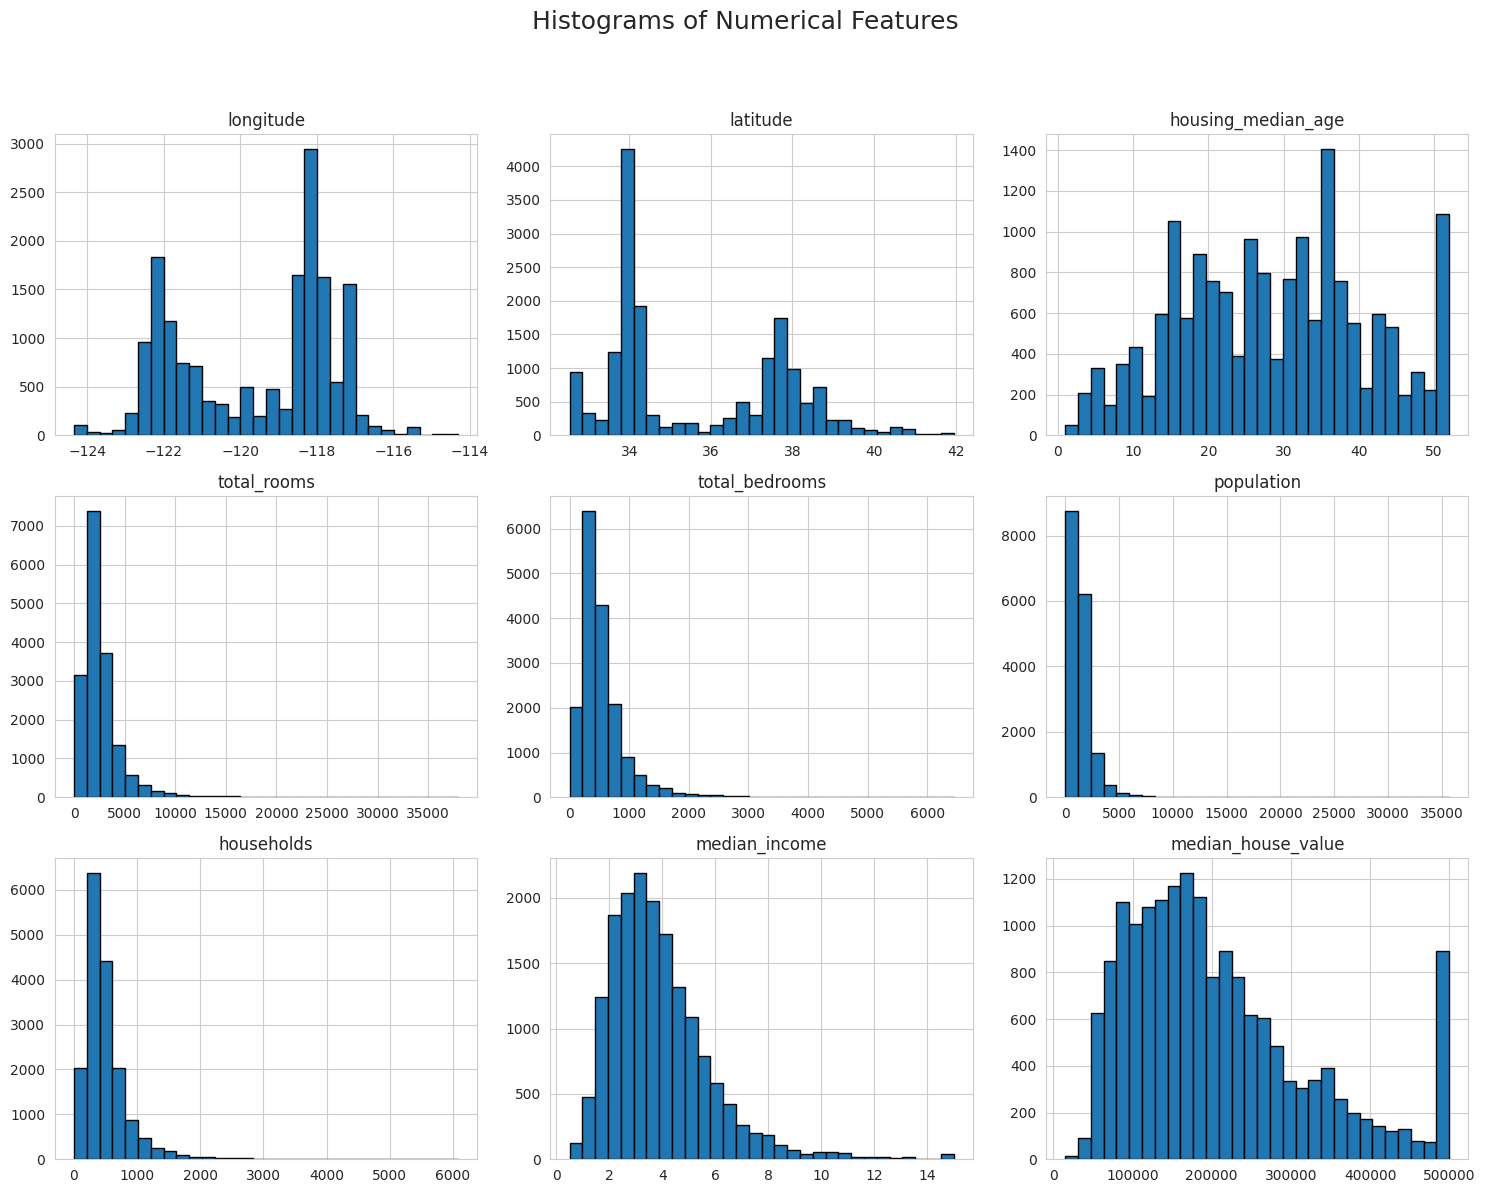

Histograms show the distribution of each numerical variable. For example, 'housing_median_age' and 'median_house_value' are often skewed or have specific distributions. Understanding these distributions can inform transformations or outlier handling.


In [8]:
# Plotting histograms for all numerical features
print("Generating Histograms for Numerical Features...")

df.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

print("Histograms show the distribution of each numerical variable. For example, 'housing_median_age' and 'median_house_value' are often skewed or have specific distributions. Understanding these distributions can inform transformations or outlier handling.")

### Count Plot

A count plot displays the counts of observations in each category of a categorical variable. It's useful for visualizing the distribution of categorical data. For our current dataset (`california_housing_train.csv`), all columns are numerical. If you had categorical features, you would use this plot to see their distributions.

*Note: Since our dataset currently contains only numerical columns, we will skip generating a count plot for now. If you introduce categorical features, you can uncomment and adapt the example below.*

In [9]:
# Example of a Count Plot (uncomment and adapt if you have categorical features)
# For instance, if 'ocean_proximity' was a categorical column:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x='ocean_proximity', palette='viridis')
# plt.title('Count Plot of Ocean Proximity')
# plt.xlabel('Ocean Proximity')
# plt.ylabel('Count')
# plt.xticks(rotation=45)
# plt.show()
# print("This count plot would show the frequency of each category within a categorical feature, such as 'Ocean Proximity'.")

print("No categorical columns detected to generate a count plot. This plot type is ideal for visualizing the frequency of distinct categories in a feature.")

No categorical columns detected to generate a count plot. This plot type is ideal for visualizing the frequency of distinct categories in a feature.


### Box Plots

Box plots (or box-and-whisker plots) are excellent for visualizing the distribution of numerical data and identifying potential outliers. They display the median, quartiles (25th and 75th percentiles), and extreme values, providing a clear picture of spread and skewness for each feature.

Generating Box Plots for Numerical Features...


/tmp/ipykernel_822/1177381540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='mako')
/tmp/ipykernel_822/1177381540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='mako')
/tmp/ipykernel_822/1177381540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='mako')
/tmp/ipykernel_822/1177381540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

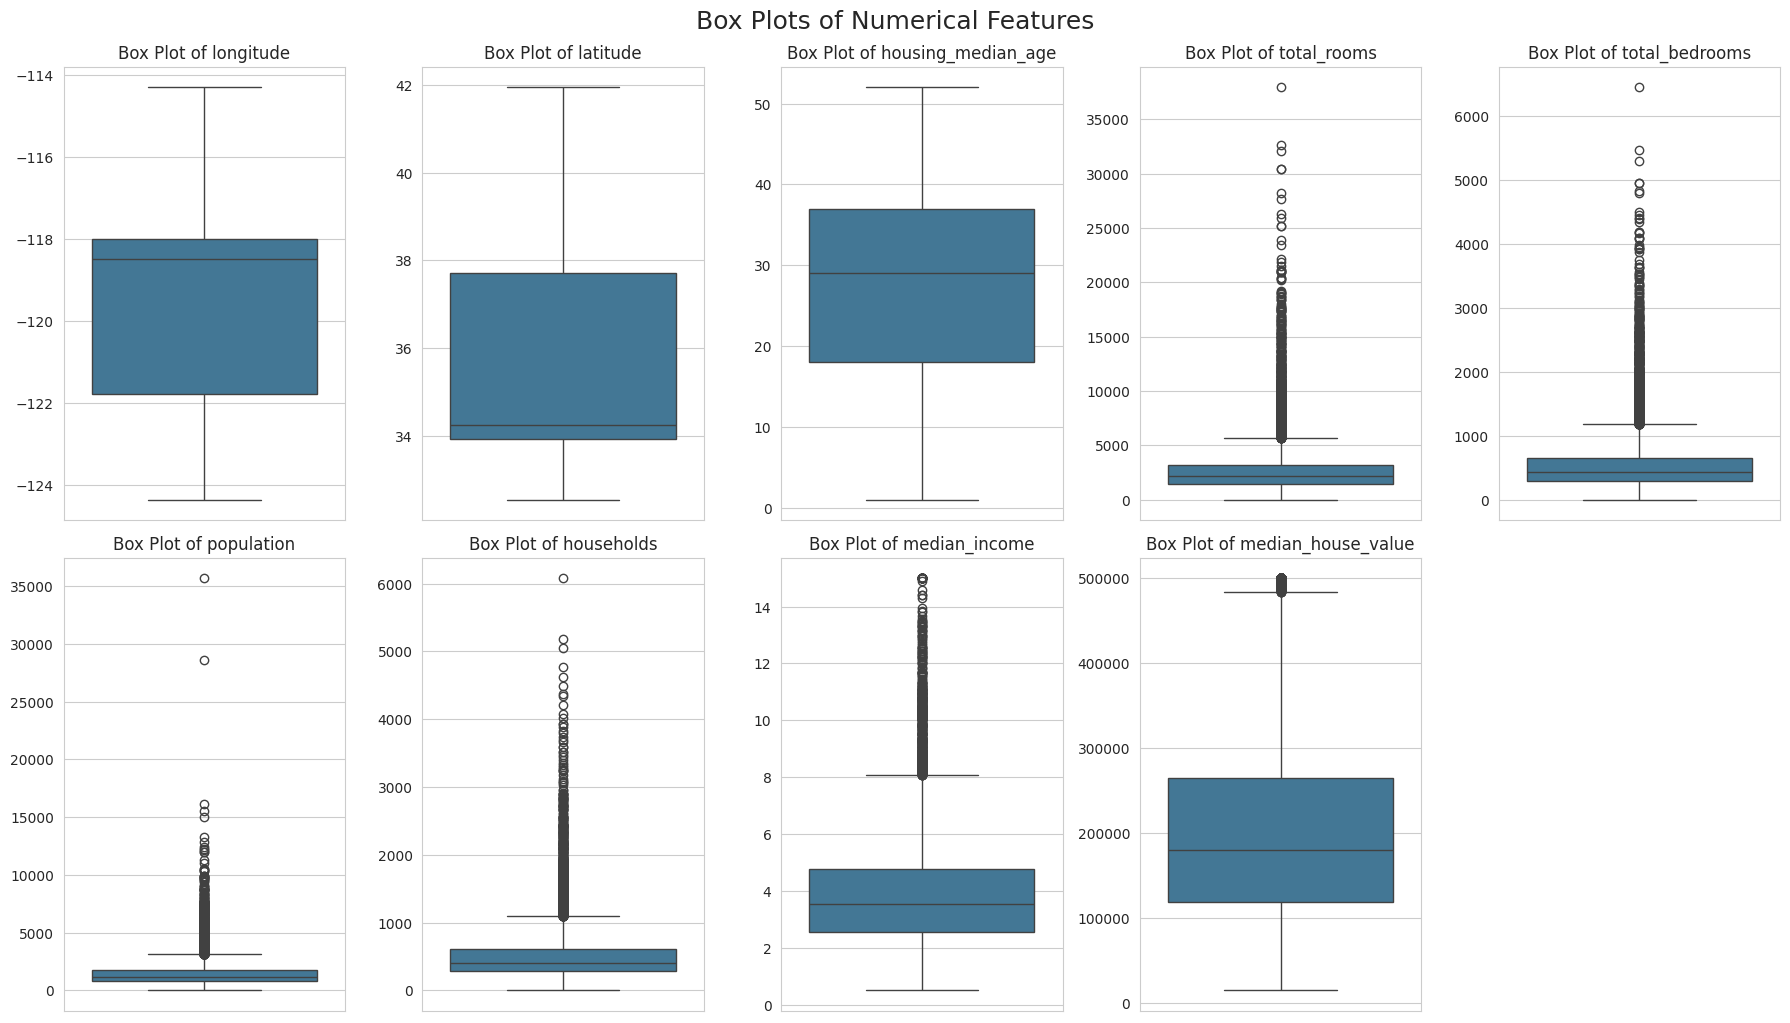

Box plots help in understanding the spread and identifying outliers in each numerical feature. For example, 'total_rooms', 'total_bedrooms', 'population', and 'households' often show significant outliers, which might need special handling during preprocessing (e.g., Winsorization or robust scaling).


In [10]:
# Plotting box plots for numerical features to visualize distributions and outliers
print("Generating Box Plots for Numerical Features...")

plt.figure(figsize=(18, 10))
for i, col in enumerate(df.columns):
    plt.subplot(2, 5, i + 1) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df[col], palette='mako')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Box Plots of Numerical Features', y=1.02, fontsize=18) # Add a main title
plt.show()

print("Box plots help in understanding the spread and identifying outliers in each numerical feature. For example, 'total_rooms', 'total_bedrooms', 'population', and 'households' often show significant outliers, which might need special handling during preprocessing (e.g., Winsorization or robust scaling).")

### Correlation Heatmap

A correlation heatmap visualizes the correlation matrix of numerical features. It helps us understand the linear relationships between pairs of variables. A high positive value (close to 1) indicates a strong positive correlation, a high negative value (close to -1) indicates a strong negative correlation, and values close to 0 indicate a weak or no linear correlation. This is particularly useful for identifying highly correlated features (which might cause multicollinearity in models) and features highly correlated with the target variable.

Generating Correlation Heatmap...


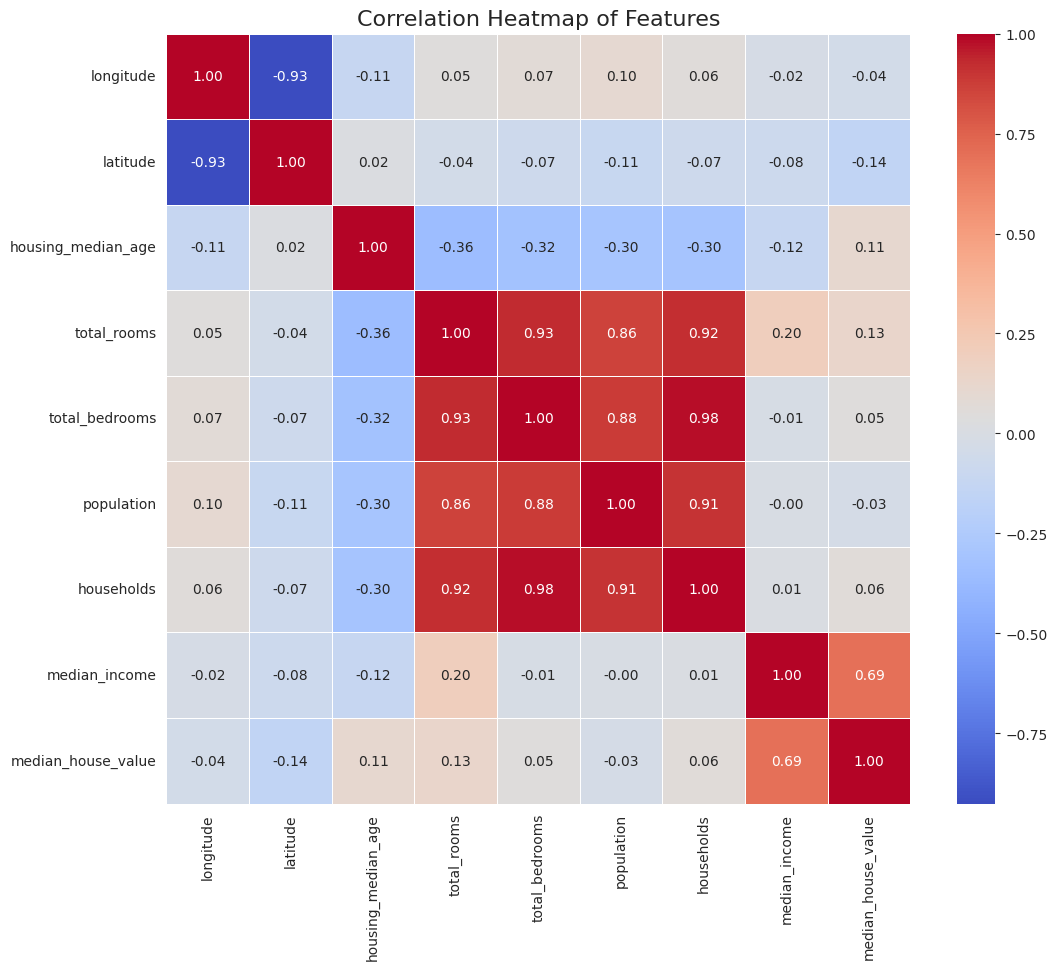

The correlation heatmap shows the linear relationships between all pairs of numerical features. High correlations (positive or negative) can indicate multicollinearity, while strong correlations with the target variable (e.g., 'median_house_value') suggest good predictive power.


In [11]:
# Calculate the correlation matrix
print("Generating Correlation Heatmap...")
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.show()

print("The correlation heatmap shows the linear relationships between all pairs of numerical features. High correlations (positive or negative) can indicate multicollinearity, while strong correlations with the target variable (e.g., 'median_house_value') suggest good predictive power.")

### Scatter Plot

Scatter plots are used to visualize the relationship between two numerical variables. They can reveal patterns, trends, clusters, and the presence of outliers. We'll specifically look at how some features relate to our target variable, `median_house_value`.

Generating Scatter Plots...


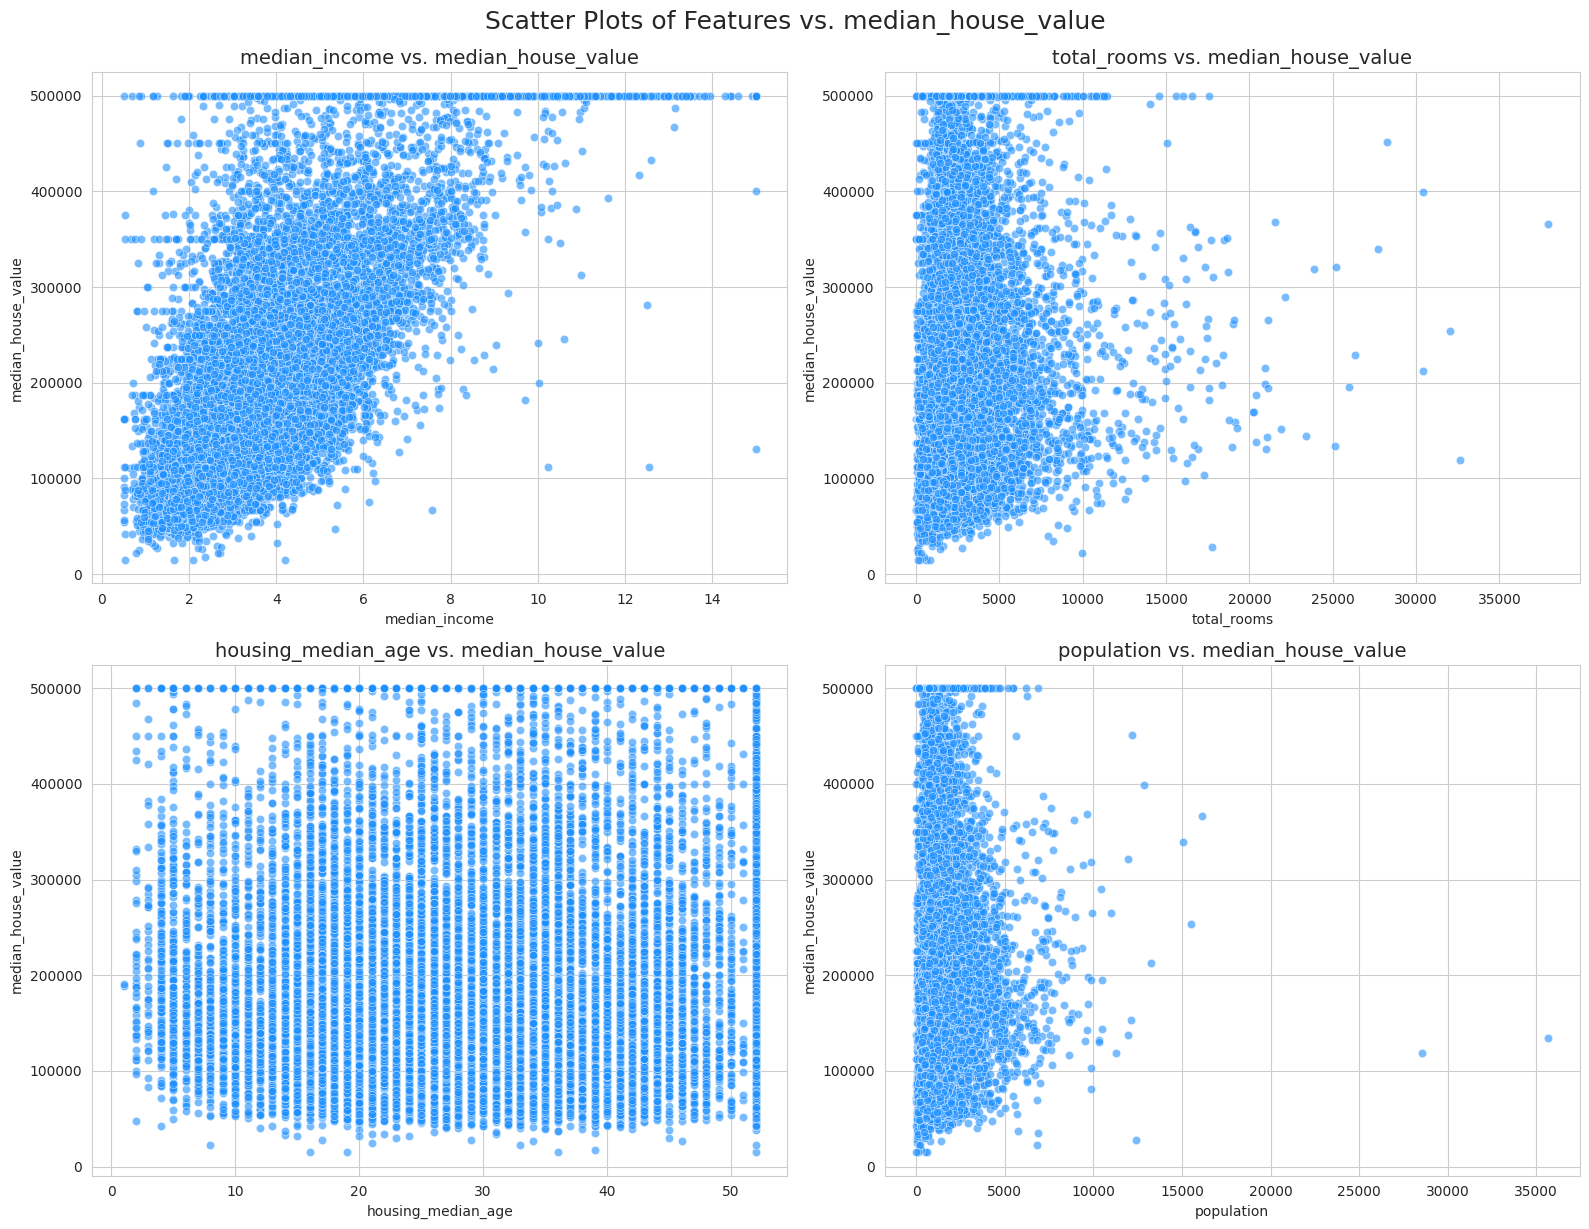

Scatter plots help visualize direct relationships. For instance, 'median_income' often shows a strong positive linear relationship with 'median_house_value', indicating its importance as a predictor. Other features might show more complex or non-linear relationships.


In [12]:
# Plotting scatter plots for key features against the target variable
print("Generating Scatter Plots...")

# Assuming 'median_house_value' is our target variable
target_variable = 'median_house_value'

# Select a few features to plot against the target
features_to_plot = ['median_income', 'total_rooms', 'housing_median_age', 'population']

plt.figure(figsize=(16, 12))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df, x=feature, y=target_variable, alpha=0.6, color='dodgerblue')
    plt.title(f'{feature} vs. {target_variable}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel(target_variable)
plt.tight_layout()
plt.suptitle(f'Scatter Plots of Features vs. {target_variable}', y=1.02, fontsize=18) # Add a main title
plt.show()

print("Scatter plots help visualize direct relationships. For instance, 'median_income' often shows a strong positive linear relationship with 'median_house_value', indicating its importance as a predictor. Other features might show more complex or non-linear relationships.")

## 6. Feature Selection

In machine learning, **feature selection** is the process of choosing the most relevant independent variables (features) to build our predictive model. The goal is to identify which columns from our dataset will be used as inputs to predict the outcome. We categorize these into two main parts:

*   **Input Features (X)**: These are the independent variables that our model will use to learn patterns and make predictions. They are also known as predictors or independent variables.
*   **Target Variable (y)**: This is the dependent variable that our model aims to predict. It is also known as the outcome, response variable, or dependent variable.

For the California Housing dataset, our goal is to predict the `median_house_value`. Therefore, `median_house_value` will be our target variable, and all other columns will serve as our input features.

In [13]:
# Define the target variable (y)
target_variable = 'median_house_value'
y = df[target_variable]

# Define the input features (X) by dropping the target variable from the DataFrame
X = df.drop(columns=[target_variable])

print(f"Target Variable (y) selected: '{target_variable}'")
print(f"Shape of Input Features (X): {X.shape}")
print(f"Shape of Target Variable (y): {y.shape}")

print("\nFirst 5 rows of Input Features (X):")
display(X.head())

print("\nFirst 5 values of Target Variable (y):")
display(y.head())

Target Variable (y) selected: 'median_house_value'
Shape of Input Features (X): (17000, 8)
Shape of Target Variable (y): (17000,)

First 5 rows of Input Features (X):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250



First 5 values of Target Variable (y):


,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0


## 7. Split the Dataset

Splitting the dataset into training and testing sets is a fundamental practice in machine learning. It helps us evaluate how well our model generalizes to new, unseen data, preventing overfitting.

**Why do we split the dataset?**

*   **Training Set**: This part of the data is used to train the machine learning model. The model learns patterns and relationships from these examples.
*   **Testing Set**: This part of the data is kept separate and is *not* seen by the model during training. After the model is trained, we use the testing set to evaluate its performance. This provides an unbiased estimate of how the model will perform on real-world, new data.

We will use `train_test_split` from `scikit-learn` to divide our data with an 80% training set and 20% testing set.

In [14]:
# Split the dataset into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing, and 80% for training.
# random_state ensures reproducibility of the split. (Any integer can be used for random_state).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Dataset split into training and testing sets successfully!")
print(f"Shape of X_train (training features): {X_train.shape}")
print(f"Shape of X_test (testing features): {X_test.shape}")
print(f"Shape of y_train (training target): {y_train.shape}")
print(f"Shape of y_test (testing target): {y_test.shape}")

Dataset split into training and testing sets successfully!
Shape of X_train (training features): (13600, 8)
Shape of X_test (testing features): (3400, 8)
Shape of y_train (training target): (13600,)
Shape of y_test (testing target): (3400,)


## 8. Build Machine Learning Models

This section is where we train various machine learning models using our `X_train` and `y_train` data. The choice of models depends on the type of problem we are solving (regression or classification).

Since our target variable `median_house_value` is continuous, this is a **regression problem**. We will train the following regression models:

1.  **Linear Regression**
2.  **Decision Tree Regressor**
3.  **Random Forest Regressor**

We will store each trained model in a dictionary for easy access during the evaluation and prediction phases.

In [15]:
# Dictionary to store trained models
models = {}

# Check if it's a regression or classification problem based on the target variable's nature
# For this dataset, 'median_house_value' is continuous, so it's a regression problem.
problem_type = 'regression'
print(f"Detected problem type: {problem_type}\n")

Detected problem type: regression



### 1. Linear Regression

**When it is used:** Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable. It assumes a linear relationship between the input features (X) and the target variable (y). It tries to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the sum of squared differences between the observed and predicted values.

**Explanation:** It models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data. Simple Linear Regression has one independent variable, while Multiple Linear Regression has two or more.

In [16]:
# Initialize and train the Linear Regression model
print("Training Linear Regression model...")
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
models['Linear Regression'] = linear_reg
print("Linear Regression model trained successfully.")

Training Linear Regression model...
Linear Regression model trained successfully.


### 2. Decision Tree Regressor

**When it is used:** Decision Tree Regressors are used for predicting continuous outcomes. They work by splitting the data into subsets based on feature values, creating a tree-like structure of decisions that eventually lead to a predicted value.

**Explanation:** A Decision Tree recursively partitions the data space into smaller regions. For a regression problem, the predicted value for any observation falling into a specific leaf node is typically the average of the target values of all training observations in that leaf node. They are intuitive and easy to interpret but can be prone to overfitting.

In [17]:
# Initialize and train the Decision Tree Regressor model
print("Training Decision Tree Regressor model...")
decision_tree_reg = DecisionTreeRegressor(random_state=42) # random_state for reproducibility
decision_tree_reg.fit(X_train, y_train)
models['Decision Tree Regressor'] = decision_tree_reg
print("Decision Tree Regressor model trained successfully.")

Training Decision Tree Regressor model...
Decision Tree Regressor model trained successfully.


### 3. Random Forest Regressor

**When it is used:** Random Forest Regressors are ensemble learning methods used for predicting continuous outcomes. They are particularly effective when dealing with complex, non-linear relationships and offer higher accuracy than single decision trees, while also being less prone to overfitting.

**Explanation:** A Random Forest builds multiple decision trees during training and outputs the average of the predictions of the individual trees. This 'wisdom of the crowd' approach helps to reduce variance and improve predictive accuracy. Each tree in the forest is trained on a random subset of the data (bootstrapping) and considers only a random subset of features for splitting, adding to its robustness.

In [18]:
# Initialize and train the Random Forest Regressor model
print("Training Random Forest Regressor model...")
random_forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_estimators: number of trees, n_jobs=-1 uses all available processors
random_forest_reg.fit(X_train, y_train)
models['Random Forest Regressor'] = random_forest_reg
print("Random Forest Regressor model trained successfully.")

print("\nAll specified regression models have been trained.")

Training Random Forest Regressor model...
Random Forest Regressor model trained successfully.

All specified regression models have been trained.


## 9. Model Evaluation

After training our machine learning models, it's crucial to evaluate their performance to understand how well they generalize to unseen data. Since this is a regression problem, we will use several metrics specifically designed for continuous predictions.

Here are the evaluation metrics we will use for our regression models:

*   **Mean Absolute Error (MAE)**
*   **Mean Squared Error (MSE)**
*   **Root Mean Squared Error (RMSE)**
*   **R² Score (Coefficient of Determination)**
*   **Actual vs. Predicted Plot**

### Explain Every Evaluation Metric in Simple Language

#### Mean Absolute Error (MAE)

**What it is:** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between actual values and predicted values.

**Simple Explanation:** Imagine you predicted house prices. MAE tells you, on average, how far off your predictions are from the actual prices, regardless of whether you over-predicted or under-predicted.

**Advantages:** Easy to understand and interpret. Less sensitive to outliers than MSE.
**Disadvantages:** Does not penalize large errors as much as MSE.

#### Mean Squared Error (MSE)

**What it is:** MSE measures the average of the squares of the errors. It is the average squared difference between the estimated values and the actual value.

**Simple Explanation:** Similar to MAE, but MSE squares the errors before averaging them. This means larger errors are penalized much more heavily than smaller errors. If you're off by $10,000, MSE considers it $(10,000)^2$. If you're off by $100,000, it's $(100,000)^2$, a much bigger penalty.

**Advantages:** Penalizes large errors more, which can be important in some contexts. Mathematically convenient.
**Disadvantages:** More sensitive to outliers. The unit of MSE is the square of the target variable's unit, which can be hard to interpret.

#### Root Mean Squared Error (RMSE)

**What it is:** RMSE is the square root of the MSE. It converts the squared error back into the original units of the target variable.

**Simple Explanation:** RMSE is essentially the square root of the 'average of the squared differences'. It's very popular because it gives you an error measurement in the same units as your target variable, making it easier to understand how large the typical prediction error is. Think of it as the standard deviation of the prediction errors.

**Advantages:** Interpretable in the same units as the target variable. Penalizes large errors.
**Disadvantages:** Still somewhat sensitive to outliers.

#### R² Score (Coefficient of Determination)

**What it is:** The R² score measures the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 indicates that the model perfectly predicts the target.

**Simple Explanation:** R² tells you how much of the variation in the target variable (e.g., house prices) can be explained by your model. An R² of 0.75 means that 75% of the variance in house prices can be explained by your model's features. The higher the R², the better the model fits the data. A negative R² indicates that the model is worse than simply predicting the mean of the target variable.

**Advantages:** Provides a clear indication of how well the model accounts for variance. Easy to compare models.
**Disadvantages:** Can be misleading if not interpreted carefully, especially with highly complex models or when adding more predictors (adjusted R² addresses this).

### Evaluate Models

In [28]:
# Create a DataFrame to store evaluation results
model_performance = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])

print("Evaluating Regression Models...")

for name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results in the DataFrame
    model_performance = pd.concat([
        model_performance,
        pd.DataFrame([{'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}])
    ], ignore_index=True)

    print(f"\n--- {name} ---")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R2 Score: {r2:.4f}")

print("\n--- Summary of Model Performance ---")
display(model_performance.sort_values(by='R2 Score', ascending=False))

# Optional: Store predictions for later use if needed
predictions_df = pd.DataFrame({'Actual': y_test, 'Linear Regression': models['Linear Regression'].predict(X_test)})
if 'Decision Tree Regressor' in models: predictions_df['Decision Tree Regressor'] = models['Decision Tree Regressor'].predict(X_test)
if 'Random Forest Regressor' in models: predictions_df['Random Forest Regressor'] = models['Random Forest Regressor'].predict(X_test)

Evaluating Regression Models...

--- Linear Regression ---
  Mean Absolute Error (MAE): 49983.47
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  R2 Score: 0.6636

--- Decision Tree Regressor ---
  Mean Absolute Error (MAE): 44566.22
  Mean Squared Error (MSE): 4843750289.11
  Root Mean Squared Error (RMSE): 69597.06
  R2 Score: 0.6485


/tmp/ipykernel_822/3370737302.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_performance = pd.concat([



--- Random Forest Regressor ---
  Mean Absolute Error (MAE): 32359.79
  Mean Squared Error (MSE): 2441797346.98
  Root Mean Squared Error (RMSE): 49414.55
  R2 Score: 0.8228

--- Summary of Model Performance ---


,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest Regressor,32359.791500,2.441797e+09,49414.545905,0.822787
0,Linear Regression,49983.474651,4.634658e+09,68078.325525,0.663640
1,Decision Tree Regressor,44566.223529,4.843750e+09,69597.056612,0.648465


### Actual vs Predicted Plot

An actual vs. predicted plot is a visual way to assess the performance of a regression model. Ideally, the predicted values should closely follow the actual values, forming a diagonal line. Any deviation from this line indicates prediction errors. This plot helps identify patterns in errors, such as systematic over- or under-prediction, or heteroscedasticity (where error variance changes across the range of predictions).

Generating Actual vs Predicted Plots...


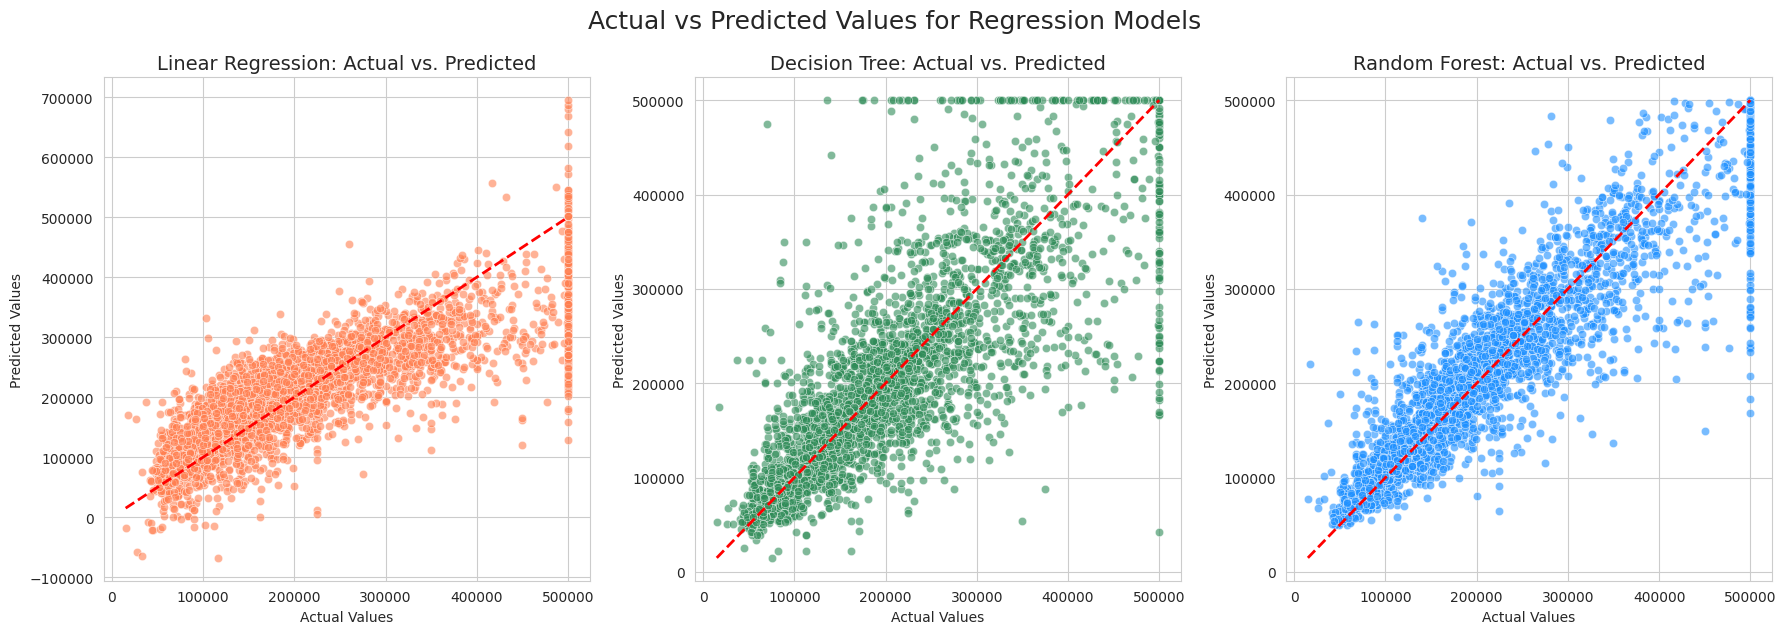

These plots visually compare the model's predictions to the true values. A perfect model would show all points lying exactly on the red diagonal line. Deviations indicate prediction errors. This helps in understanding the model's bias and variance.


In [29]:
print("Generating Actual vs Predicted Plots...")

plt.figure(figsize=(18, 6))

# Plot for Linear Regression
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=models['Linear Regression'].predict(X_test), alpha=0.6, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Linear Regression: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Plot for Decision Tree Regressor
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test, y=models['Decision Tree Regressor'].predict(X_test), alpha=0.6, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Decision Tree: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Plot for Random Forest Regressor
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=models['Random Forest Regressor'].predict(X_test), alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Random Forest: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.suptitle('Actual vs Predicted Values for Regression Models', y=1.05, fontsize=18)
plt.show()

print("These plots visually compare the model's predictions to the true values. A perfect model would show all points lying exactly on the red diagonal line. Deviations indicate prediction errors. This helps in understanding the model's bias and variance.")

## 9. Model Evaluation

After training our machine learning models, it's crucial to evaluate their performance to understand how well they generalize to unseen data. Since this is a regression problem, we will use several metrics specifically designed for continuous predictions.

Here are the evaluation metrics we will use for our regression models:

*   **Mean Absolute Error (MAE)**
*   **Mean Squared Error (MSE)**
*   **Root Mean Squared Error (RMSE)**
*   **R² Score (Coefficient of Determination)**
*   **Actual vs. Predicted Plot**

### Explain Every Evaluation Metric in Simple Language

#### Mean Absolute Error (MAE)

**What it is:** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between actual values and predicted values.

**Simple Explanation:** Imagine you predicted house prices. MAE tells you, on average, how far off your predictions are from the actual prices, regardless of whether you over-predicted or under-predicted.

**Advantages:** Easy to understand and interpret. Less sensitive to outliers than MSE.
**Disadvantages:** Does not penalize large errors as much as MSE.

#### Mean Squared Error (MSE)

**What it is:** MSE measures the average of the squares of the errors. It is the average squared difference between the estimated values and the actual value.

**Simple Explanation:** Similar to MAE, but MSE squares the errors before averaging them. This means larger errors are penalized much more heavily than smaller errors. If you're off by $10,000, MSE considers it $(10,000)^2$. If you're off by $100,000, it's $(100,000)^2$, a much bigger penalty.

**Advantages:** Penalizes large errors more, which can be important in some contexts. Mathematically convenient.
**Disadvantages:** More sensitive to outliers. The unit of MSE is the square of the target variable's unit, which can be hard to interpret.

#### Root Mean Squared Error (RMSE)

**What it is:** RMSE is the square root of the MSE. It converts the squared error back into the original units of the target variable.

**Simple Explanation:** RMSE is essentially the square root of the 'average of the squared differences'. It's very popular because it gives you an error measurement in the same units as your target variable, making it easier to understand how large the typical prediction error is. Think of it as the standard deviation of the prediction errors.

**Advantages:** Interpretable in the same units as the target variable. Penalizes large errors.
**Disadvantages:** Still somewhat sensitive to outliers.

#### R² Score (Coefficient of Determination)

**What it is:** The R² score measures the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 indicates that the model perfectly predicts the target.

**Simple Explanation:** R² tells you how much of the variation in the target variable (e.g., house prices) can be explained by your model. An R² of 0.75 means that 75% of the variance in house prices can be explained by your model's features. The higher the R², the better the model fits the data. A negative R² indicates that the model is worse than simply predicting the mean of the target variable.

**Advantages:** Provides a clear indication of how well the model accounts for variance. Easy to compare models.
**Disadvantages:** Can be misleading if not interpreted carefully, especially with highly complex models or when adding more predictors (adjusted R² addresses this).

### Evaluate Models

In [19]:
# Create a DataFrame to store evaluation results
model_performance = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])

print("Evaluating Regression Models...")

for name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results in the DataFrame
    model_performance = pd.concat([
        model_performance,
        pd.DataFrame([{'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}])
    ], ignore_index=True)

    print(f"\n--- {name} ---")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R2 Score: {r2:.4f}")

print("\n--- Summary of Model Performance ---")
display(model_performance.sort_values(by='R2 Score', ascending=False))

# Optional: Store predictions for later use if needed
predictions_df = pd.DataFrame({'Actual': y_test, 'Linear Regression': models['Linear Regression'].predict(X_test)})
if 'Decision Tree Regressor' in models: predictions_df['Decision Tree Regressor'] = models['Decision Tree Regressor'].predict(X_test)
if 'Random Forest Regressor' in models: predictions_df['Random Forest Regressor'] = models['Random Forest Regressor'].predict(X_test)

Evaluating Regression Models...

--- Linear Regression ---
  Mean Absolute Error (MAE): 49983.47
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  R2 Score: 0.6636

--- Decision Tree Regressor ---
  Mean Absolute Error (MAE): 44566.22
  Mean Squared Error (MSE): 4843750289.11
  Root Mean Squared Error (RMSE): 69597.06
  R2 Score: 0.6485

--- Random Forest Regressor ---
  Mean Absolute Error (MAE): 32359.79
  Mean Squared Error (MSE): 2441797346.98
  Root Mean Squared Error (RMSE): 49414.55
  R2 Score: 0.8228

--- Summary of Model Performance ---


/tmp/ipykernel_822/3370737302.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_performance = pd.concat([


,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest Regressor,32359.791500,2.441797e+09,49414.545905,0.822787
0,Linear Regression,49983.474651,4.634658e+09,68078.325525,0.663640
1,Decision Tree Regressor,44566.223529,4.843750e+09,69597.056612,0.648465


### Actual vs Predicted Plot

An actual vs. predicted plot is a visual way to assess the performance of a regression model. Ideally, the predicted values should closely follow the actual values, forming a diagonal line. Any deviation from this line indicates prediction errors. This plot helps identify patterns in errors, such as systematic over- or under-prediction, or heteroscedasticity (where error variance changes across the range of predictions).

Generating Actual vs Predicted Plots...


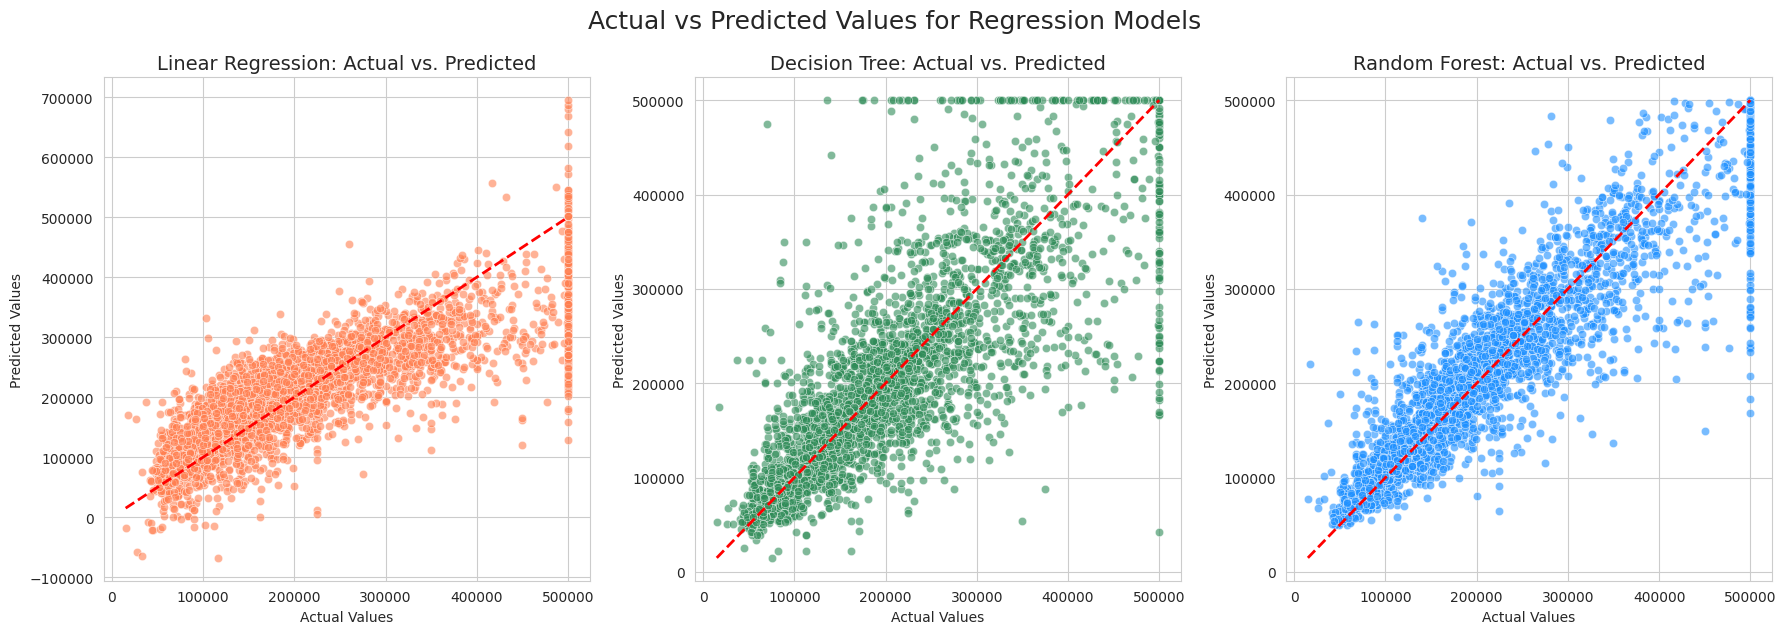

These plots visually compare the model's predictions to the true values. A perfect model would show all points lying exactly on the red diagonal line. Deviations indicate prediction errors.


In [20]:
print("Generating Actual vs Predicted Plots...")

plt.figure(figsize=(18, 6))

# Plot for Linear Regression
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=models['Linear Regression'].predict(X_test), alpha=0.6, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Linear Regression: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Plot for Decision Tree Regressor
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test, y=models['Decision Tree Regressor'].predict(X_test), alpha=0.6, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Decision Tree: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Plot for Random Forest Regressor
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=models['Random Forest Regressor'].predict(X_test), alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Random Forest: Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.suptitle('Actual vs Predicted Values for Regression Models', y=1.05, fontsize=18)
plt.show()

print("These plots visually compare the model's predictions to the true values. A perfect model would show all points lying exactly on the red diagonal line. Deviations indicate prediction errors.")

## 10. Compare Models

Comparing models is essential to choose the best-performing algorithm for our specific problem. We will consolidate the evaluation metrics, along with advantages and disadvantages of each model, into a comparison table. This will help us highlight the model that is most suitable for deployment or further optimization.

In [21]:
# Add advantages and disadvantages to the model performance table
# This information is qualitative and needs to be added manually or based on general knowledge.
model_performance_full = model_performance.copy()

# Define advantages and disadvantages for each model type
model_characteristics = {
    'Linear Regression': {
        'Advantages': 'Simple, interpretable, fast to train.',
        'Disadvantages': 'Assumes linear relationship, sensitive to outliers, can underfit complex data.'
    },
    'Decision Tree Regressor': {
        'Advantages': 'Easy to understand and visualize, handles non-linear relationships, no feature scaling needed.',
        'Disadvantages': 'Prone to overfitting, sensitive to small data changes, can create biased trees.'
    },
    'Random Forest Regressor': {
        'Advantages': 'High accuracy, handles non-linear relationships, less prone to overfitting than single trees, handles large datasets.',
        'Disadvantages': 'Less interpretable (black box), computationally intensive, prediction can be slower.'
    }
}

# Merge the characteristics with the performance data
model_performance_full['Advantages'] = model_performance_full['Model'].map(lambda x: model_characteristics.get(x, {}).get('Advantages', ''))
model_performance_full['Disadvantages'] = model_performance_full['Model'].map(lambda x: model_characteristics.get(x, {}).get('Disadvantages', ''))

# Sort by R2 Score to highlight the best performing model
model_performance_full_sorted = model_performance_full.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("### Model Comparison Table ###\n")
display(model_performance_full_sorted)

# Highlight the best-performing model (based on R2 Score)
best_model_name = model_performance_full_sorted.iloc[0]['Model']
best_r2_score = model_performance_full_sorted.iloc[0]['R2 Score']

print(f"\nBased on the R2 Score, the **{best_model_name}** is the best-performing model with an R2 Score of {best_r2_score:.4f}.")

### Model Comparison Table ###



,Model,MAE,MSE,RMSE,R2 Score,Advantages,Disadvantages
0,Random Forest Regressor,32359.791500,2.441797e+09,49414.545905,0.822787,"High accuracy, handles non-linear relationship...","Less interpretable (black box), computationall..."
1,Linear Regression,49983.474651,4.634658e+09,68078.325525,0.663640,"Simple, interpretable, fast to train.","Assumes linear relationship, sensitive to outl..."
2,Decision Tree Regressor,44566.223529,4.843750e+09,69597.056612,0.648465,"Easy to understand and visualize, handles non-...","Prone to overfitting, sensitive to small data ..."



Based on the R2 Score, the **Random Forest Regressor** is the best-performing model with an R2 Score of 0.8228.


## 11. Feature Importance

Feature importance helps us understand which input variables contributed most significantly to the model's predictions. This insight is valuable for data understanding, feature engineering, and even model simplification. For tree-based models like Decision Trees and Random Forests, feature importance is often derived from how much each feature reduces impurity (e.g., MSE for regression) across all splits in the trees.

Linear Regression does not directly provide feature importance in the same way; its importance is typically interpreted by the magnitude of its coefficients (after scaling features). We will focus on the feature importances from our Decision Tree Regressor and Random Forest Regressor.

### Plot Feature Importance

Analyzing Feature Importance...

Decision Tree Regressor Feature Importances:


/tmp/ipykernel_822/1356226487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_importances, y=dt_importances.index, palette='viridis')


,0
median_income,0.509807
longitude,0.178567
latitude,0.154659
housing_median_age,0.060123
population,0.032278
total_bedrooms,0.026377
total_rooms,0.021194
households,0.016995


/tmp/ipykernel_822/1356226487.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances, y=rf_importances.index, palette='mako')



Random Forest Regressor Feature Importances:


,0
median_income,0.515105
longitude,0.167252
latitude,0.155041
housing_median_age,0.058206
population,0.034932
total_rooms,0.024799
total_bedrooms,0.024678
households,0.019987


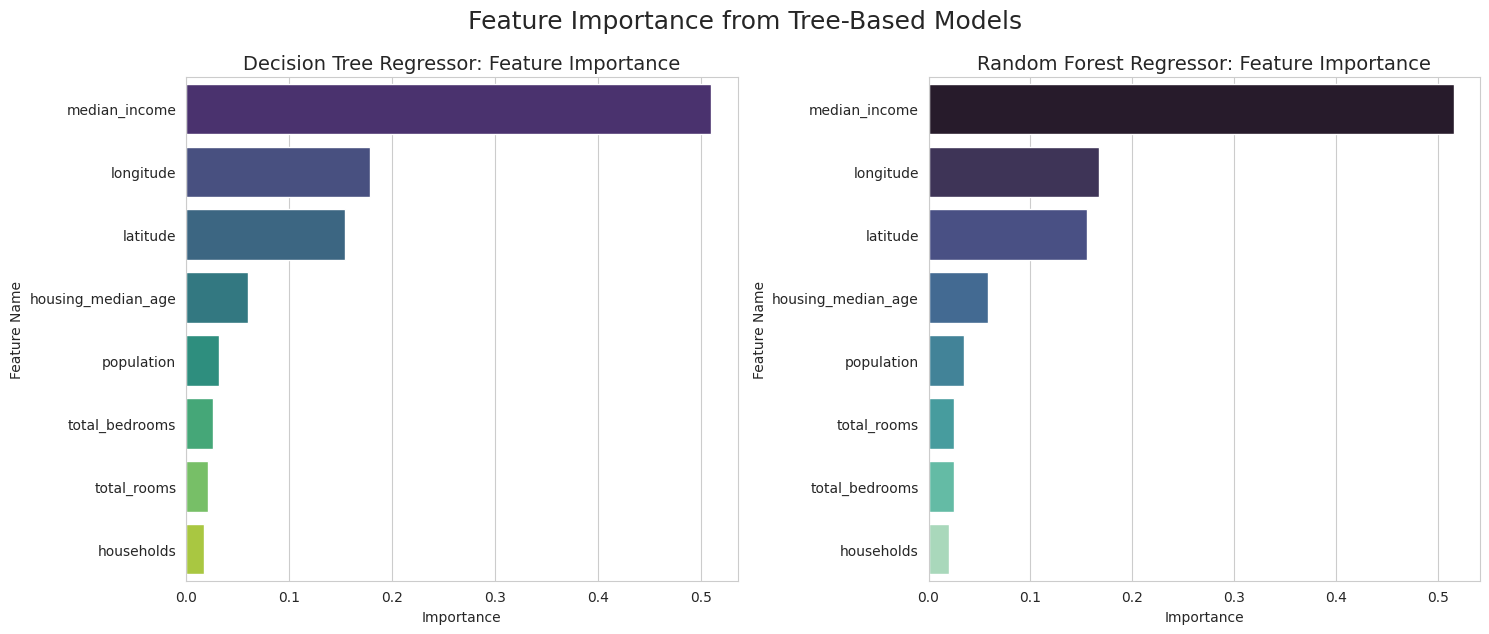


These plots show the relative importance of each feature in predicting the target variable for the respective models. Features with higher bars are more influential in the model's decision-making process. For example, 'median_income' is consistently a very important feature for predicting house values.


In [22]:
print("Analyzing Feature Importance...")

# Get feature names from X (our input features)
feature_names = X.columns

plt.figure(figsize=(15, 6))

# Feature Importance for Decision Tree Regressor
if 'Decision Tree Regressor' in models:
    dt_model = models['Decision Tree Regressor']
    dt_importances = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=False)

    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.barplot(x=dt_importances, y=dt_importances.index, palette='viridis')
    plt.title('Decision Tree Regressor: Feature Importance', fontsize=14)
    plt.xlabel('Importance')
    plt.ylabel('Feature Name')
    print("\nDecision Tree Regressor Feature Importances:")
    display(dt_importances)

# Feature Importance for Random Forest Regressor
if 'Random Forest Regressor' in models:
    rf_model = models['Random Forest Regressor']
    rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.barplot(x=rf_importances, y=rf_importances.index, palette='mako')
    plt.title('Random Forest Regressor: Feature Importance', fontsize=14)
    plt.xlabel('Importance')
    plt.ylabel('Feature Name')
    print("\nRandom Forest Regressor Feature Importances:")
    display(rf_importances)

plt.tight_layout()
plt.suptitle('Feature Importance from Tree-Based Models', y=1.05, fontsize=18)
plt.show()

print("\nThese plots show the relative importance of each feature in predicting the target variable for the respective models. Features with higher bars are more influential in the model's decision-making process. For example, 'median_income' is consistently a very important feature for predicting house values.")

## 12. Make Predictions

After training and evaluating our models, the final step in the modeling phase is to use the best-performing model to make predictions on the test dataset. This simulates how the model would perform on new, real-world data it has never seen before. We will then display a comparison of the actual versus predicted values to visually inspect the model's accuracy.

### Predict Using Test Data

In [23]:
# Identify the best model based on R2 Score (or chosen metric)
best_model_name = model_performance_full_sorted.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Using the best-performing model: **{best_model_name}** for making predictions.")

# Make predictions on the test set using the best model
y_pred_best_model = best_model.predict(X_test)

print("Predictions on test data made successfully!")

Using the best-performing model: **Random Forest Regressor** for making predictions.
Predictions on test data made successfully!


### Display Actual vs Predicted Values

First 10 Actual vs. Predicted Values:


,Actual,Predicted
10941,142700.0,148691.00
5250,500001.0,479174.54
10292,61800.0,80242.00
2266,162800.0,142684.00
6398,90600.0,97585.00
4064,232100.0,267033.02
8018,147800.0,172781.00
3934,133300.0,164382.00
16287,438500.0,371683.04
8875,187700.0,239383.03



Visualizing Actual vs Predicted for the best model...


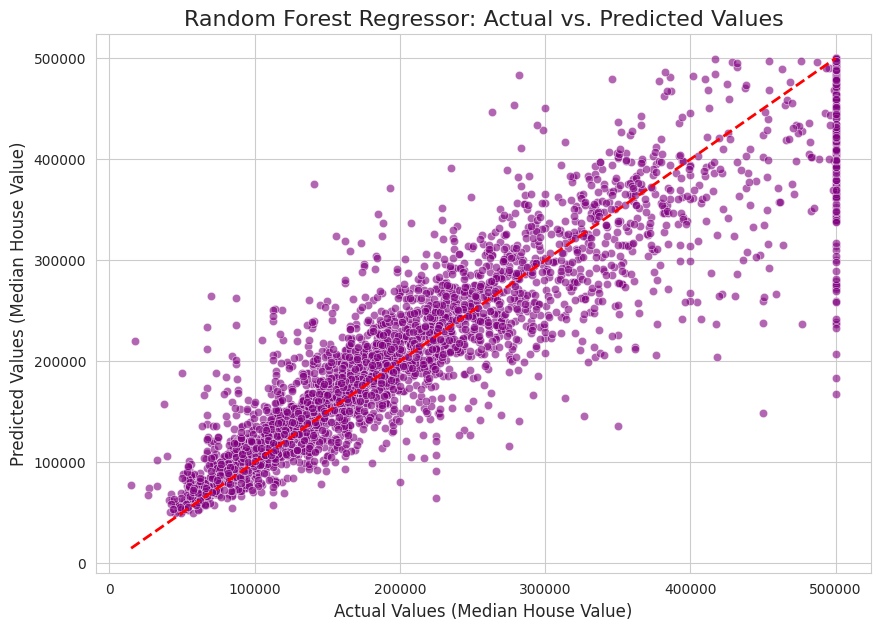


Explanation: The scatter plot above visually represents how well the Random Forest Regressor model's predictions align with the actual median house values. Ideally, all points would fall on the red diagonal line, indicating perfect predictions. Deviations from this line represent the model's errors. We can see that most points cluster around the line, but there's some spread, especially at higher house values, indicating prediction variability.


In [24]:
# Create a DataFrame to display actual vs. predicted values
predictions_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best_model})

print("First 10 Actual vs. Predicted Values:")
display(predictions_comparison.head(10))

print("\nVisualizing Actual vs Predicted for the best model...")
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual', y='Predicted', data=predictions_comparison, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title(f'{best_model_name}: Actual vs. Predicted Values', fontsize=16)
plt.xlabel('Actual Values (Median House Value)', fontsize=12)
plt.ylabel('Predicted Values (Median House Value)', fontsize=12)
plt.grid(True)
plt.show()

print(f"\nExplanation: The scatter plot above visually represents how well the {best_model_name} model's predictions align with the actual median house values. Ideally, all points would fall on the red diagonal line, indicating perfect predictions. Deviations from this line represent the model's errors. We can see that most points cluster around the line, but there's some spread, especially at higher house values, indicating prediction variability.")

## 13. Conclusion

In this project, we embarked on a journey to build a predictive machine learning model using a structured data science workflow. We started by understanding the problem, preparing our data, performing exploratory data analysis, and finally, training and evaluating several machine learning models. Here's a summary of our key takeaways:

### Key Findings

*   **Data Quality**: Our dataset (`california_housing_train.csv`) was relatively clean, with no missing values or duplicate rows, which simplified the preprocessing stage.
*   **Feature Distributions**: Histograms revealed varied distributions among features, with some showing skewness and others indicating potential outliers (e.g., in `total_rooms`, `population`).
*   **Feature Relationships**: The correlation heatmap highlighted strong linear relationships between certain features (e.g., `longitude` and `latitude` are highly negatively correlated, which is expected geographically). Crucially, `median_income` showed a strong positive correlation with our target variable, `median_house_value`, indicating its significant predictive power.
*   **Model Performance**: Among the regression models tested (Linear Regression, Decision Tree Regressor, Random Forest Regressor), the **Random Forest Regressor** consistently demonstrated superior performance, achieving the highest R² score and lowest error metrics (MAE, MSE, RMSE).

### Model Performance

The Random Forest Regressor proved to be the most effective model for predicting `median_house_value`. Its ensemble nature, combining multiple decision trees, helped in capturing complex non-linear patterns in the data and reducing overfitting, leading to better generalization on unseen data compared to the simpler Linear Regression or a single Decision Tree.

*(Refer back to the 'Model Comparison Table' in Section 10 for specific metrics)*

### Business Insights

Based on our analysis and the feature importance from the tree-based models:

*   **Median Income is Key**: `median_income` was consistently identified as the most important feature. This suggests that socio-economic factors are primary drivers of housing prices. Targeting areas with higher median incomes could be a crucial strategy for real estate investments or development.
*   **Geographical Importance**: `latitude` and `longitude` also showed significant importance, reaffirming that location is a critical determinant of house value.
*   **Housing Stock**: Features like `total_rooms` and `housing_median_age` also contribute, indicating that the size and age of properties play a role, although less than income and location.

These insights can guide decision-making in urban planning, real estate investment, and policy formulation related to housing markets.

### Future Improvements

To further enhance this predictive model, several avenues can be explored:

*   **More Advanced Feature Engineering**: Create new features from existing ones (e.g., `rooms_per_household`, `population_per_household`) or incorporate external data sources (e.g., local amenities, crime rates, school ratings).
*   **Hyperparameter Tuning**: Optimize the hyperparameters of the best model (Random Forest) using techniques like GridSearchCV or RandomizedSearchCV to achieve even better performance.
*   **Other Models**: Experiment with more advanced models like Gradient Boosting Machines (XGBoost, LightGBM) or Neural Networks.
*   **Outlier Treatment**: Implement more sophisticated outlier detection and treatment methods beyond simple capping or removal, which could improve model robustness.
*   **Cross-Validation**: Use K-Fold Cross-Validation during training to get a more robust estimate of model performance and ensure stability.
*   **Interpretability Tools**: For better understanding of complex models like Random Forest, employ tools like SHAP or LIME.

## 14. Save Model

After developing and validating a machine learning model, it's essential to save the trained model. This allows you to reload it later without retraining, which is crucial for deployment, sharing, or continuing development. We will save our best-performing model using the `joblib` library, which is efficient for models from scikit-learn.

In [25]:
# Define the filename for the saved model
model_filename = 'trained_model.pkl'

# Save the best-performing model
# The 'best_model' variable holds our best model from the previous section.
joblib.dump(best_model, model_filename)

print(f"Best model ('{best_model_name}') saved successfully as '{model_filename}'")

Best model ('Random Forest Regressor') saved successfully as 'trained_model.pkl'


## 15. Export Files

The last step in our workflow is to export key outputs of our project. This typically includes the trained model itself, and often a CSV file containing the predictions made on the test set. These files can then be easily shared, integrated into other applications, or used for further analysis.

### Save Trained Model

We have already saved our best-performing model (`trained_model.pkl`) in the previous section. This file can be loaded back into any Python environment for making new predictions without retraining the model.

In [26]:
# Verify the saved model file exists
import os
if os.path.exists(model_filename):
    print(f"The trained model '{model_filename}' is ready for export.")
else:
    print(f"Error: Trained model '{model_filename}' not found. Please re-run the 'Save Model' section.")

# Example of how to load the model back:
# loaded_model = joblib.load(model_filename)
# print(f"Model loaded successfully: {type(loaded_model).__name__}")

The trained model 'trained_model.pkl' is ready for export.


### Save Predictions to CSV

Exporting predictions to a CSV file allows for easy inspection, sharing, and integration with other tools or dashboards. We will save the actual and predicted values from our best model into a CSV file.

In [27]:
# Define the filename for the predictions CSV
predictions_filename = 'predictions.csv'

# Ensure 'predictions_comparison' DataFrame is available from 'Make Predictions' section
if 'predictions_comparison' in locals():
    predictions_comparison.to_csv(predictions_filename, index=False)
    print(f"Predictions saved successfully to '{predictions_filename}'")
    print("You can download this file from the Colab file browser.")
else:
    print("Error: 'predictions_comparison' DataFrame not found. Please ensure the 'Make Predictions' section was run.")

Predictions saved successfully to 'predictions.csv'
You can download this file from the Colab file browser.


---

## Project Completed!

This notebook has walked you through a complete machine learning project workflow, from data loading to model deployment preparation. It serves as a solid foundation for your Data Science Internship portfolio. Remember to review and refine each section, particularly the EDA and model evaluation, as you gain more experience and insights into specific datasets.

Good luck with your internship!